In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Tuple

# ── helpers ──────────────────────────────────────────────────────────────────

def load_sensor(path: str, required_cols: list[str]) -> pd.DataFrame:
    df = pd.read_csv(path).sort_values("timestamp_ms").reset_index(drop=True)
    missing = set(required_cols) - set(df.columns)
    if missing:
        raise ValueError(f"{path}: missing columns {missing}")
    return df

def clip_to_overlap(
    *dfs: pd.DataFrame, col: str = "timestamp_ms"
) -> Tuple[pd.DataFrame, ...]:
    t_start = max(df[col].min() for df in dfs)
    t_end   = min(df[col].max() for df in dfs)
    overlap_s = (t_end - t_start) / 1_000
    if overlap_s <= 0:
        raise ValueError("No temporal overlap between sensors.")
    print(f"Overlap window : {t_start} → {t_end}  ({overlap_s:.1f} s)")
    return tuple(
        df[(df[col] >= t_start) & (df[col] <= t_end)].reset_index(drop=True)
        for df in dfs
    )

def sample_rate_stats(df: pd.DataFrame, label: str, col: str = "timestamp_ms"):
    dt = df[col].diff().dropna() / 1_000          # ms → s
    hz = 1 / dt
    print(f"\n{label} — {len(df)} samples")
    print(f"  dt  : mean={dt.mean():.4f}s  std={dt.std():.4f}s  "
          f"min={dt.min():.4f}s  max={dt.max():.4f}s")
    print(f"  rate: mean={hz.mean():.1f} Hz  std={hz.std():.2f} Hz")
    return dt

# ── GPS dedup ─────────────────────────────────────────────────────────────────
# Keep the sample closest to the median timestamp within each UTC second.
# More representative than tail(1) when the last sample may be an edge burst.

def dedup_gps_per_second(gps: pd.DataFrame) -> pd.DataFrame:
    def pick_median(g):
        median_t = g["timestamp_ms"].median()
        return g.iloc[(g["timestamp_ms"] - median_t).abs().argmin()]
    return (
        gps.groupby("utc_seconds", group_keys=False)
           .apply(pick_median)
           .reset_index(drop=True)
    )

# ── main pipeline ─────────────────────────────────────────────────────────────
GPS_COLS = ["timestamp_ms", "latitude", "longitude", "speed_mps", "course_deg", "altitude_m"]
IMU_COLS = ["timestamp_ms", "accel_x", "accel_y", "accel_z", "gyro_x", "gyro_y", "gyro_z"]

gps_raw = load_sensor("gps.csv", GPS_COLS)
imu_raw = load_sensor("imu.csv", IMU_COLS)

print(f"GPS raw : {gps_raw.shape}")
print(f"IMU raw : {imu_raw.shape}")

gps_dedup = dedup_gps_per_second(gps_raw)
print(f"\nGPS after dedup: {gps_raw.shape[0]} → {gps_dedup.shape[0]} samples")

gps, imu = clip_to_overlap(gps_dedup, imu_raw)
print(f"\nGPS clipped : {gps.shape}")
print(f"IMU clipped : {imu.shape}")

dt_gps = sample_rate_stats(gps, "GPS")
dt_imu = sample_rate_stats(imu, "IMU")

GPS raw : (1094, 8)
IMU raw : (55190, 8)

GPS after dedup: 1094 → 545 samples
Overlap window : 236771.0 → 787783.0  (551.0 s)

GPS clipped : (545, 8)
IMU clipped : (55101, 8)

GPS — 545 samples
  dt  : mean=1.0129s  std=0.1622s  min=0.8190s  max=3.8760s
  rate: mean=1.0 Hz  std=0.05 Hz

IMU — 55101 samples
  dt  : mean=0.0100s  std=0.0026s  min=0.0000s  max=0.5080s
  rate: mean=inf Hz  std=nan Hz


/tmp/ipykernel_3007/1574740197.py:48: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(pick_median)


In [ ]:
def find_gaps(df: pd.DataFrame, label: str, col: str = "timestamp_ms", multiplier: float = 2.0):
    dt = df[col].diff() / 1_000
    expected_dt = dt.median()
    threshold = multiplier * expected_dt

    gap_idx = dt[dt > threshold].index
    gaps = pd.DataFrame({
        "gap_start_s" : df.loc[gap_idx - 1, col].values / 1000,
        "gap_end_s"   : df.loc[gap_idx,     col].values / 1000,
        "duration_s"  : dt[gap_idx].values,
        "missed_samples" : (dt[gap_idx] / expected_dt).astype(int).values,
    })
    gaps["t_mid_s"] = (gaps["gap_start_s"] + gaps["gap_end_s"]) / 2

    print(f"\n{label} gaps (> {threshold:.3f}s = {multiplier}× median dt):")
    print(gaps.to_string(index=False))
    return gaps

gaps_gps = find_gaps(gps, "GPS")
gaps_imu = find_gaps(imu, "IMU")


GPS gaps (> 2.000s = 2.0× median dt):
 gap_start_s  gap_end_s  duration_s  missed_samples  t_mid_s
     396.908    400.784       3.876               3 398.8460
     571.769    573.781       2.012               2 572.7750
     573.781    576.776       2.995               2 575.2785
     762.770    764.772       2.002               2 763.7710

IMU gaps (> 0.020s = 2.0× median dt):
 gap_start_s  gap_end_s  duration_s  missed_samples  t_mid_s
     314.394    314.421       0.027               2 314.4075
     320.394    320.424       0.030               3 320.4090
     357.394    357.421       0.027               2 357.4075
     436.694    436.781       0.087               8 436.7375
     436.894    436.969       0.075               7 436.9315
     437.394    437.538       0.144              14 437.4660
     456.784    456.880       0.096               9 456.8320
     456.884    457.065       0.181              18 456.9745
     457.394    457.547       0.153              15 457.4705
     48

In [ ]:
import numpy as np

GRAVITY = np.array([0, 0, 9.80665])

# ── Helpers ───────────────────────────────────────────────────────────────────
def skew(v: np.ndarray) -> np.ndarray:
    return np.array([
        [ 0,    -v[2],  v[1]],
        [ v[2],  0,    -v[0]],
        [-v[1],  v[0],  0   ],
    ])

def rotvec_to_quat(v: np.ndarray) -> np.ndarray:
    """Small-angle rotation vector → unit quaternion [w, x, y, z]."""
    angle = np.linalg.norm(v)
    if angle < 1e-8:                          # first-order approx avoids /0
        return np.array([1.0, v[0]/2, v[1]/2, v[2]/2])
    axis = v / angle
    return np.array([np.cos(angle/2), *(np.sin(angle/2) * axis)])

def quat_mult(p: np.ndarray, q: np.ndarray) -> np.ndarray:
    """Hamilton product of two quaternions [w, x, y, z]."""
    pw, px, py, pz = p
    qw, qx, qy, qz = q
    return np.array([
        pw*qw - px*qx - py*qy - pz*qz,
        pw*qx + px*qw + py*qz - pz*qy,
        pw*qy - px*qz + py*qw + pz*qx,
        pw*qz + px*qy - py*qx + pz*qw,
    ])

def quat_to_rot(q: np.ndarray) -> np.ndarray:
    """Unit quaternion [w,x,y,z] → 3×3 rotation matrix (body→world)."""
    w, x, y, z = q
    return np.array([
        [1-2*(y*y+z*z),   2*(x*y-w*z),   2*(x*z+w*y)],
        [  2*(x*y+w*z), 1-2*(x*x+z*z),   2*(y*z-w*x)],
        [  2*(x*z-w*y),   2*(y*z+w*x), 1-2*(x*x+y*y)],
    ])

GRAVITY = np.array([0.0, 0.0, 9.81])   # ENU: z apunta hacia arriba


# ── Attitude EKF ──────────────────────────────────────────────────────────────

class AttitudeEKF:
    def __init__(self):
        # ── Nominal state ─────────────────────────────────────────────────
        self.q  = np.array([1.0, 0.0, 0.0, 0.0])  # quaternion [w, x, y, z]
        self.bg = np.zeros(3)                        # gyro bias estimate (rad/s)
        self.ba = np.zeros(3)                        # acc bias estimate (rad/s)

        # ── Error state δx = [δθ(3), δbg(3), δba(3)] ─────────────────────────────
        # Reset to zero after every update step (error-state convention)
        self.dx = np.zeros(9)

        # ── Covariances ───────────────────────────────────────────────────
        self.P = np.diag([
            0.1,  0.1,  0.1,    # orientation uncertainty  (rad²)
            0.01, 0.01, 0.01,   # bias uncertainty         (rad²/s²)
            0.01, 0.01, 0.01,   # bias uncertainty         (m²/s²)
        ])

        self.Q = np.diag([
            5e-3, 5e-3, 5e-3,   # gyro white noise         (rad²/s)
            1e-6, 1e-6, 1e-6,   # bias random walk         (rad²/s³)
            1e-5, 1e-5, 1e-5,   # bias random walk         (m²/s³)
        ])

        # ── Noise ───────────────────────────────────────────────────
        self.R_acc = np.diag([5e-2, 5e-2, 5e-2])    # accel noise (tune per sensor)


    # ── Predict (gyroscope integration) ──────────────────────────────────────
    def predict(self, gyro: np.ndarray, dt: float):
        w = gyro - self.bg                      # bias-corrected angular velocity

        # 1. Propagate nominal quaternion
        dq = rotvec_to_quat(w * dt)
        self.q = quat_mult(self.q, dq)
        self.q /= np.linalg.norm(self.q)        # keep unit norm

        # 2. Error-state transition matrix
        F = np.eye(9)
        F[0:3, 0:3] = np.eye(3) - skew(w) * dt  # ∂δθ/∂δθ
        F[0:3, 3:6] = -np.eye(3) * dt            # ∂δθ/∂δbg

        # 3. Discrete noise input matrix
        G = np.zeros((9, 9))
        G[0:3, 0:3] = np.eye(3) * dt
        G[3:6, 3:6] = np.eye(3) * dt
        G[6:9, 6:9] = np.eye(3) * dt
        # 4. Propagate error-state covariance
        self.P = F @ self.P @ F.T + G @ self.Q @ G.T

    def _apply_correction(self, dx: np.ndarray):
        """Inject error-state correction into nominal state, then reset."""
        self.q  = quat_mult(self.q, rotvec_to_quat(dx[0:3]))
        self.q /= np.linalg.norm(self.q)
        self.bg += dx[3:6]
        self.ba += dx[6:9]
        self.dx  = np.zeros(9)

    def _kalman_update(self, residual: np.ndarray, H: np.ndarray, R: np.ndarray):
        """Generic KF measurement update. Returns corrected dx."""
        S  = H @ self.P @ H.T + R                        # innovation covariance
        K  = self.P @ H.T @ np.linalg.inv(S)             # Kalman gain
        dx = K @ residual                                 # error-state correction
        self.P = (np.eye(9) - K @ H) @ self.P            # covariance update
        return dx

    # ── Update 1: accelerometer (roll + pitch) ────────────────────────────────
    def update_accel(self, acc: np.ndarray, gate: float = 0.5):
        """
        Correct roll/pitch using accelerometer as gravity reference.
        Skipped when vehicle dynamics dominate (quasi-static gate).

        gate : max allowed deviation from 9.81 m/s² to accept update (m/s²)
        """
        acc_corr = acc - self.ba
        acc_mag = np.linalg.norm(acc_corr)
        if abs(acc_mag - 9.81) > gate:       # vehicle is accelerating → skip
            return

        a_norm = acc_corr / acc_mag               # unit gravity direction, body frame

        R      = quat_to_rot(self.q)
        g_pred = R.T @ (GRAVITY / 9.81)     # expected unit gravity in body frame

        residual = a_norm - g_pred           # (3,)

        # H: gravity measurement is sensitive to δθ, not δbg
        H = np.zeros((3, 9))
        H[0:3, 0:3] = skew(g_pred)          # ∂g_body/∂δθ
        H[0:3, 6:9] = -np.eye(3)

        dx = self._kalman_update(residual, H, self.R_acc)
        self._apply_correction(dx)

    def update_heading(self, heading_rad: float, heading_std_rad: float = 0.1):
        """
        Correct yaw using GPS-derived heading (course over ground).
        Only reliable above ~1 m/s — caller should gate on speed.

        heading_rad     : course-over-ground in ENU (rad, 0=East, CCW+)
        heading_std_rad : 1-sigma heading noise (rad)
        """
        R   = quat_to_rot(self.q)
        yaw = np.arctan2(R[1, 0], R[0, 0])  # yaw extracted from rotation matrix

        residual = np.array([heading_rad - yaw])

        # wrap to [-π, π]
        residual[0] = (residual[0] + np.pi) % (2 * np.pi) - np.pi

        # H: only yaw component of δθ affects heading measurement
        H       = np.zeros((1, 9))
        H[0, 2] = 1.0                        # ∂heading/∂δθ_z

        R_hdg = np.array([[heading_std_rad ** 2]])

        dx = self._kalman_update(residual, H, R_hdg)
        self._apply_correction(dx)

    def angular_velocity(self, gyro: np.ndarray):
        return gyro - self.bg

    def linear_acceleration(self, acc: np.ndarray) -> np.ndarray:
        """
        Compute linear acceleration in world frame (gravity removed).

        acc : raw accelerometer (body frame, m/s^2)

        returns: linear acceleration in world frame (m/s^2)
        """
        # 1. Rotación body → world
        acc_corr = acc - self.ba
        R = quat_to_rot(self.q)
        acc_world = R @ acc_corr
        # 2. Quitar gravedad
        lin_acc = acc_world - GRAVITY

        return lin_acc

    def acceleration(self, acc: np.ndarray):
        return acc - self.ba

    def orientation(self) -> dict:
        """
        Returns current attitude in three representations.

        euler_deg : (roll, pitch, yaw) in degrees  — intuitive for debugging
        euler_rad : (roll, pitch, yaw) in radians  — use for further math
        quaternion: [w, x, y, z]                   — canonical internal form
        R         : 3×3 rotation matrix body→world
        """
        R = quat_to_rot(self.q)

        # Aerospace ZYX convention: yaw → pitch → roll
        pitch = np.arcsin(-R[2, 0])
        roll  = np.arctan2(R[2, 1], R[2, 2])
        yaw   = np.arctan2(R[1, 0], R[0, 0])

        euler_rad = np.array([roll, pitch, yaw])

        return euler_rad

In [ ]:
imu_segment = imu.iloc[:int(0.01 * len(imu))].copy()

# ── 3. Limpieza básica ────────────────────────────────────────────────────────
imu_segment = (
    imu_segment
    .drop_duplicates(subset="timestamp_ms")
    .sort_values("timestamp_ms")
    .reset_index(drop=True)
)

# ── GYRO VAR ────────────────────────────────────────────────
gyro = imu_segment[["gyro_x", "gyro_y", "gyro_z"]].values
gyro_var = np.var(gyro, axis=0)

print("Gyro variance (rad^2/s^2):", gyro_var)

# ── ACCEL VAR (normalizado) ─────────────────────────────────
acc = imu_segment[["accel_x", "accel_y", "accel_z"]].values
acc_norm = acc / np.linalg.norm(acc, axis=1, keepdims=True)

acc_var = np.var(acc_norm, axis=0)

print("Accel variance (unit^2):", acc_var)

Gyro variance (rad^2/s^2): [9.40685916e-05 5.04650957e-05 1.09290713e-03]
Accel variance (unit^2): [3.52510839e-04 1.19155546e-04 5.18590840e-08]


In [ ]:
imu["timestamp_ms"] = imu["timestamp_ms"].astype(np.int64)
gps["timestamp_ms"] = gps["timestamp_ms"].astype(np.int64)

# merge (IMU timeline dominante)
imu_with_gps = pd.merge_asof(
    imu.sort_values("timestamp_ms"),
    gps[["timestamp_ms", "speed_mps", "course_deg"]],
    on="timestamp_ms",
    direction="nearest",
    tolerance=200  # ms (ajusta si hace falta)
)

print(imu.shape)
print(gps.shape)
print(imu_with_gps.shape)

(55101, 8)
(5509, 10)
(55101, 10)


In [ ]:
import numpy as np
import pandas as pd

# ─────────────────────────────────────────────────────────────
# Low-pass filter helper
# ─────────────────────────────────────────────────────────────
def lpf(prev, new, alpha=0.9):
    return alpha * prev + (1 - alpha) * new

def gps_course_to_enu_deg(course_deg):
    # GPS: 0° = North, clockwise positive
    # ENU: 0° = East, CCW positive

    yaw_rad = np.deg2rad(90.0 - course_deg)

    # wrap to [-pi, pi]
    yaw_rad = np.arctan2(np.sin(yaw_rad), np.cos(yaw_rad))

    return np.rad2deg(yaw_rad)

# ─────────────────────────────────────────────────────────────
# 3. EKF loop
# ─────────────────────────────────────────────────────────────
ekf = AttitudeEKF()
results = []

total = int(len(imu_with_gps) - 1)
# ── LPF state memory ──────────────────────────────────────────
gyro_f  = np.zeros(3)
acc_f   = np.zeros(3)

alpha_gyro = 0.95
alpha_acc  = 0.9
gyro_f_history = []
acc_f_history = []

lina_acc_ekf_history = []

for i in range(1, total + 1):

    # progress bar
    if i % 500 == 0 or i == total:
        pct = 100 * i / total
        print(f"\r[{'█' * int(pct // 5):<20}] {pct:5.1f}% ({i}/{total})", end="", flush=True)

    # time delta
    t_curr = imu_with_gps["timestamp_ms"].iloc[i]
    t_prev = imu_with_gps["timestamp_ms"].iloc[i - 1]
    dt = (t_curr - t_prev) / 1000.0

    if dt <= 0 or dt > 0.1:
        continue

    row = imu_with_gps.iloc[i]

    # raw sensors
    gyro_raw  = row[["gyro_x", "gyro_y", "gyro_z"]].values.astype(float)
    acc_raw   = row[["accel_x", "accel_y", "accel_z"]].values.astype(float)

    # ── LOW PASS FILTER ───────────────────────────────────────
    gyro_f = lpf(gyro_f, gyro_raw, alpha_gyro)
    acc_f  = lpf(acc_f, acc_raw, alpha_acc)

    # EKF predict/update
    ekf.predict(gyro_f, dt)
    ekf.update_accel(acc_f)

    # ── GPS heading update (careful!)
    course = row["course_deg"]
    speed  = row["speed_mps"]

    if (
        not np.isnan(course)
        and not np.isnan(speed)
        and speed > 1
    ):
        ekf.update_heading(np.radians(gps_course_to_enu_deg(course)), 0.5)

    # linear acceleration (post-filtering optional)
    lin_acc = ekf.linear_acceleration(acc_f)

    # output
    roll, pitch, yaw = ekf.orientation()

    gyro_f_history.append(gyro_f.copy())
    acc_f_history.append(acc_f.copy())
    lina_acc_ekf_history.append(lin_acc.copy())

    results.append({
        "t": t_curr,
        "gx": gyro_f[0],
        "gy": gyro_f[1],
        "gz": gyro_f[2],
        "ax": acc_f[0],
        "ay": acc_f[1],
        "az": acc_f[2],
        "alin_x": lin_acc[0],
        "alin_y": lin_acc[1],
        "alin_z": lin_acc[2],
        "roll": np.degrees(roll),
        "pitch": np.degrees(pitch),
        "yaw": np.degrees(yaw),
    })

print("\nDone.")

df = pd.DataFrame(results)

print(df[["roll", "pitch", "yaw"]].describe())
print(df[["ax", "ay", "az"]].describe())

[████████████████████] 100.0% (55100/55100)
Done.
               roll         pitch           yaw
count  55018.000000  55018.000000  55018.000000
mean      -2.147521     -1.944313     -8.543263
std        2.247033      3.245517    117.101708
min       -8.386620    -13.554830   -179.999086
25%       -3.100376     -3.402559   -143.743171
50%       -2.584890     -1.825155     40.479989
75%       -1.827146     -0.234049     84.552199
max        9.994321      6.280365    179.997960
                 ax            ay            az
count  55018.000000  55018.000000  55018.000000
mean       0.113044     -0.311370      9.567996
std        0.639754      0.364949      0.254806
min       -1.933403     -1.580136      0.929750
25%       -0.253498     -0.459555      9.484341
50%       -0.003245     -0.375507      9.569116
75%        0.323115     -0.241663      9.652016
max        2.994454      2.244587     12.916694


In [ ]:
df = pd.DataFrame(results)
df.to_csv("ekf_output.csv", index=False)

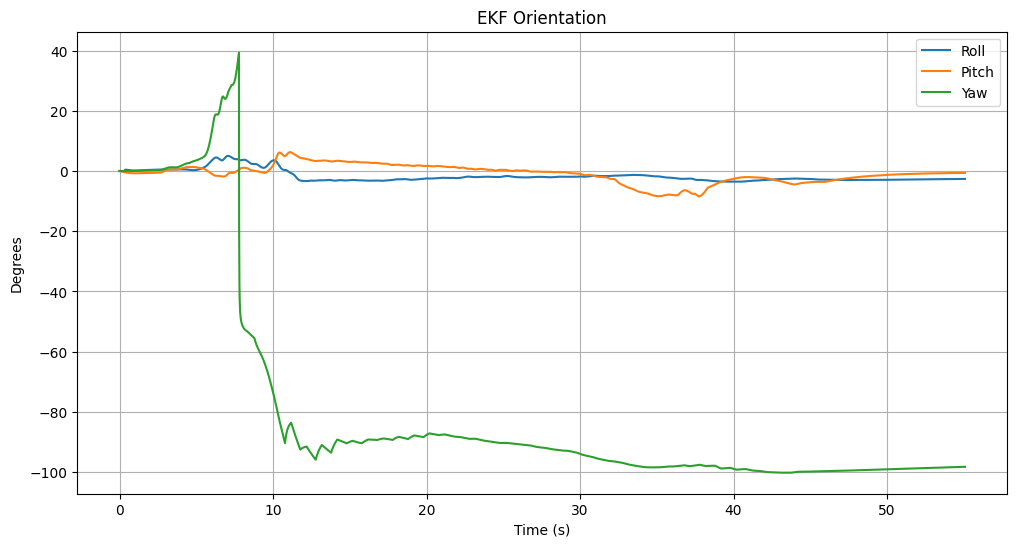

In [ ]:
# convert time to seconds relative to start
t = (df["t"] - df["t"].iloc[0]) / 1000.0

plt.figure(figsize=(12, 6))

plt.plot(t, df["roll"],  label="Roll")
plt.plot(t, df["pitch"], label="Pitch")
plt.plot(t, df["yaw"],   label="Yaw")

plt.xlabel("Time (s)")
plt.ylabel("Degrees")
plt.title("EKF Orientation")
plt.legend()
plt.grid(True)

plt.show()

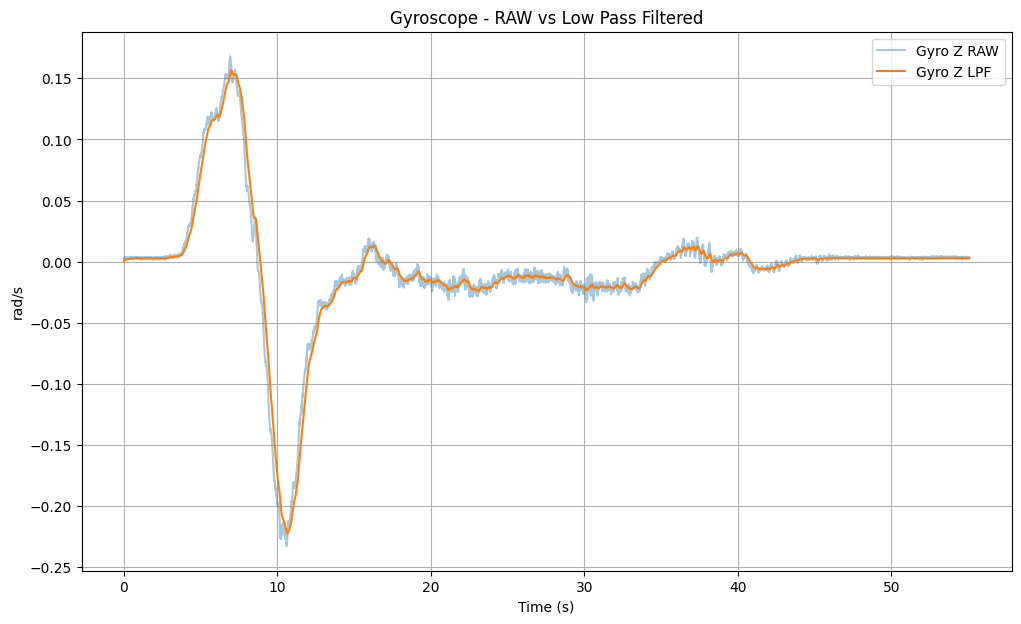

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

gyro_f_history = np.array(gyro_f_history)

t = (imu_with_gps["timestamp_ms"].values[:len(gyro_f_history)]
     - imu_with_gps["timestamp_ms"].iloc[0]) / 1000.0

gyro_raw_all = imu_with_gps[["gyro_x", "gyro_y", "gyro_z"]].values[:len(gyro_f_history)]

plt.figure(figsize=(12, 7))

# # ── X axis ─────────────────────────────────────────────
# plt.plot(t, gyro_raw_all[:, 0], label="Gyro X RAW", alpha=0.4)
# plt.plot(t, gyro_f_history[:, 0], label="Gyro X LPF")

# # ── Y axis ─────────────────────────────────────────────
# plt.plot(t, gyro_raw_all[:, 1], label="Gyro Y RAW", alpha=0.4)
# plt.plot(t, gyro_f_history[:, 1], label="Gyro Y LPF")

# ── Z axis ─────────────────────────────────────────────
plt.plot(t, gyro_raw_all[:, 2], label="Gyro Z RAW", alpha=0.4)
plt.plot(t, gyro_f_history[:, 2], label="Gyro Z LPF")

plt.title("Gyroscope - RAW vs Low Pass Filtered")
plt.xlabel("Time (s)")
plt.ylabel("rad/s")
plt.legend()
plt.grid()
plt.show()

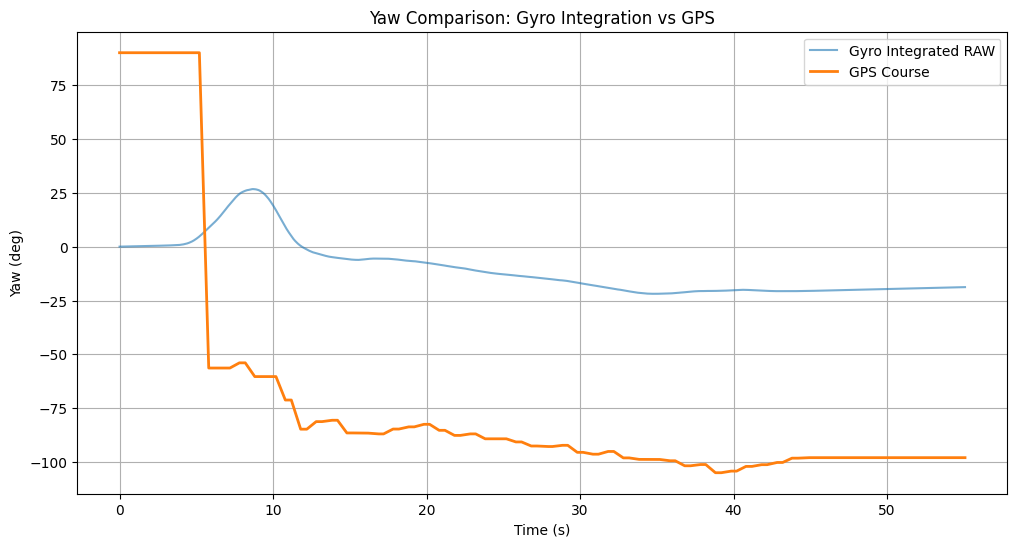

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# ── time ─────────────────────────────────────────────
t = (imu_with_gps["timestamp_ms"].values[:len(gyro_f_history)]
     - imu_with_gps["timestamp_ms"].iloc[0]) / 1000.0

dt = np.diff(t, prepend=t[0])

# ── gyro z ───────────────────────────────────────────
gyro_z_raw = imu_with_gps["gyro_z"].values[:len(gyro_f_history)]
gyro_z_f   = gyro_f_history[:, 2]

# ── integrate gyro → yaw ─────────────────────────────
yaw_raw = np.cumsum(gyro_z_raw * dt)
yaw_f   = np.cumsum(gyro_z_f * dt)

# ── GPS course (CLEAN) ───────────────────────────────
gps_course = gps_course_to_enu_deg(imu_with_gps["course_deg"].values[:len(gyro_f_history)])

valid = ~np.isnan(gps_course)

t_gps = t[valid]
yaw_gps = np.radians(gps_course[valid])

# unwrap safely
yaw_raw_u = np.unwrap(yaw_raw)
yaw_f_u   = np.unwrap(yaw_f)
yaw_gps_u = np.unwrap(yaw_gps)

# ── plot ─────────────────────────────────────────────
plt.figure(figsize=(12, 6))

plt.plot(t, np.degrees(yaw_raw_u), label="Gyro Integrated RAW", alpha=0.6)
plt.plot(t_gps, np.degrees(yaw_gps_u), label="GPS Course", linewidth=2)

plt.title("Yaw Comparison: Gyro Integration vs GPS")
plt.xlabel("Time (s)")
plt.ylabel("Yaw (deg)")
plt.legend()
plt.grid()
plt.show()

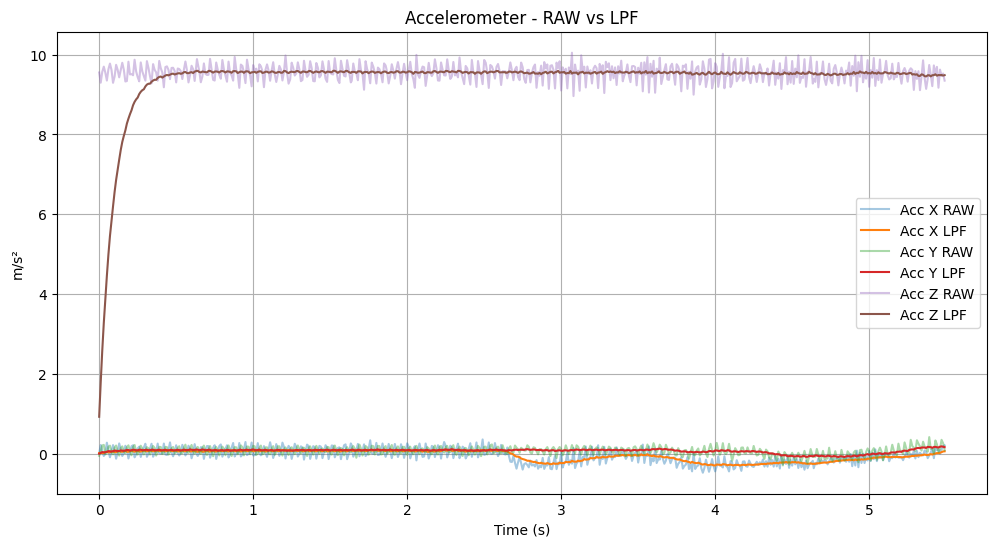

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

acc_f_history = np.array(acc_f_history)

t = (imu_with_gps["timestamp_ms"].values[:len(acc_f_history)]
     - imu_with_gps["timestamp_ms"].iloc[0]) / 1000.0

acc_raw_all = imu_with_gps[["accel_x", "accel_y", "accel_z"]].values[:len(acc_f_history)]

plt.figure(figsize=(12, 6))

# X axis
plt.plot(t, acc_raw_all[:, 0], label="Acc X RAW", alpha=0.4)
plt.plot(t, acc_f_history[:, 0], label="Acc X LPF")

# Y axis
plt.plot(t, acc_raw_all[:, 1], label="Acc Y RAW", alpha=0.4)
plt.plot(t, acc_f_history[:, 1], label="Acc Y LPF")

# Z axis
plt.plot(t, acc_raw_all[:, 2], label="Acc Z RAW", alpha=0.4)
plt.plot(t, acc_f_history[:, 2], label="Acc Z LPF")

plt.title("Accelerometer - RAW vs LPF")
plt.xlabel("Time (s)")
plt.ylabel("m/s²")
plt.legend()
plt.grid()
plt.show()

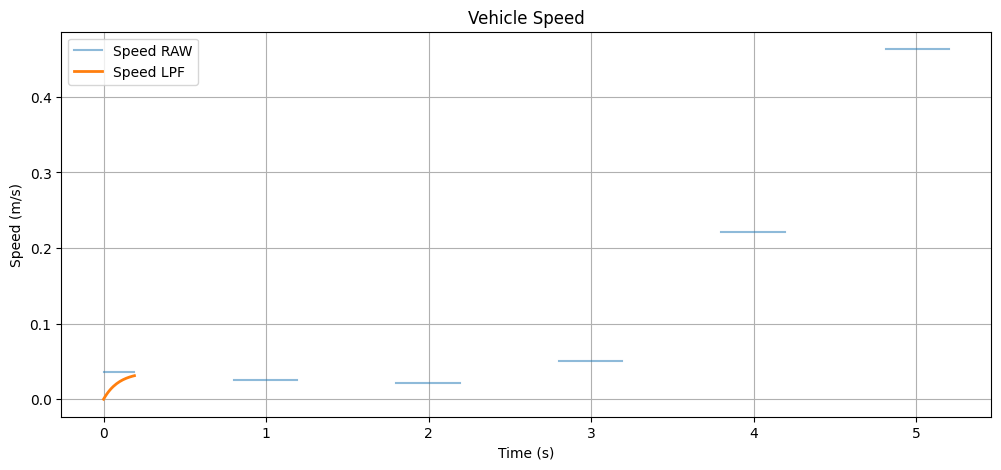

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ── time ─────────────────────────────────────────────
t = (imu_with_gps["timestamp_ms"].values[:len(gyro_f_history)]
     - imu_with_gps["timestamp_ms"].iloc[0]) / 1000.0

# ── raw speed ─────────────────────────────────────────
speed_raw = imu_with_gps["speed_mps"].values[:len(gyro_f_history)]

# ── optional: low-pass filter speed ───────────────────
def lpf(prev, new, alpha=0.9):
    return alpha * prev + (1 - alpha) * new

speed_f = np.zeros_like(speed_raw)
for i in range(1, len(speed_raw)):
    speed_f[i] = lpf(speed_f[i-1], speed_raw[i], alpha=0.9)

# ── plot ─────────────────────────────────────────────
plt.figure(figsize=(12, 5))

plt.plot(t, speed_raw, label="Speed RAW", alpha=0.5)
plt.plot(t, speed_f, label="Speed LPF", linewidth=2)

plt.title("Vehicle Speed")
plt.xlabel("Time (s)")
plt.ylabel("Speed (m/s)")
plt.legend()
plt.grid()
plt.show()

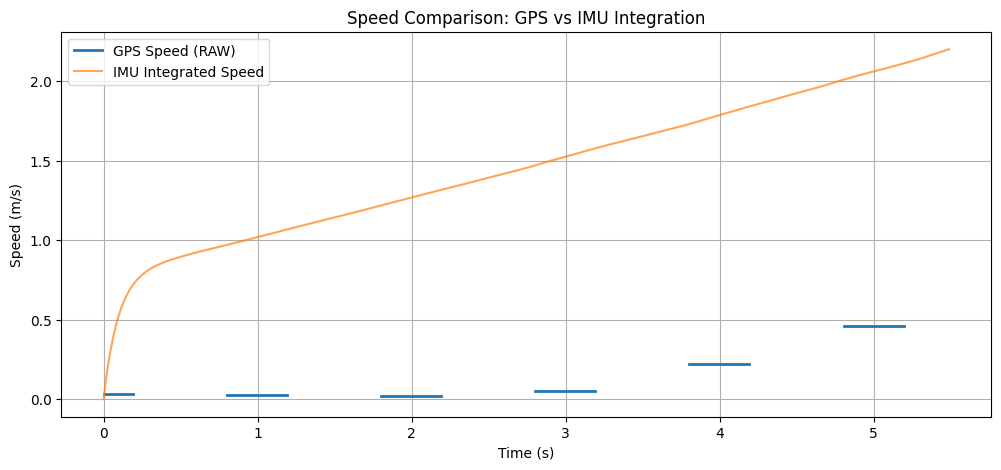

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ── time ─────────────────────────────────────────────
t = (imu_with_gps["timestamp_ms"].values[:len(gyro_f_history)]
     - imu_with_gps["timestamp_ms"].iloc[0]) / 1000.0

dt = np.diff(t, prepend=t[0])

# ── GPS speed (RAW ONLY) ─────────────────────────────
speed_gps = imu_with_gps["speed_mps"].values[:len(gyro_f_history)]

# ── IMU linear acceleration (already EKF-corrected) ─
acc = np.array(lina_acc_ekf_history)

# ── integrate acceleration → velocity ───────────────
vel_imu = np.zeros(3)
vel_imu_history = []

for i in range(len(acc)):
    vel_imu += acc[i] * dt[i]
    vel_imu_history.append(vel_imu.copy())

vel_imu_history = np.array(vel_imu_history)

# speed magnitude
speed_imu = np.linalg.norm(vel_imu_history, axis=1)

# ── plot ─────────────────────────────────────────────
plt.figure(figsize=(12, 5))

plt.plot(t, speed_gps, label="GPS Speed (RAW)", linewidth=2)
plt.plot(t, speed_imu, label="IMU Integrated Speed", alpha=0.7)

plt.title("Speed Comparison: GPS vs IMU Integration")
plt.xlabel("Time (s)")
plt.ylabel("Speed (m/s)")
plt.legend()
plt.grid()
plt.show()

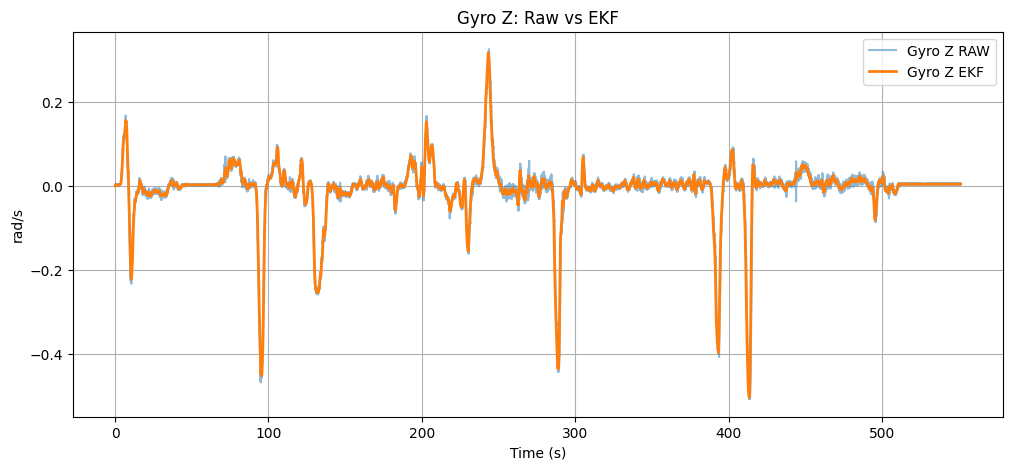

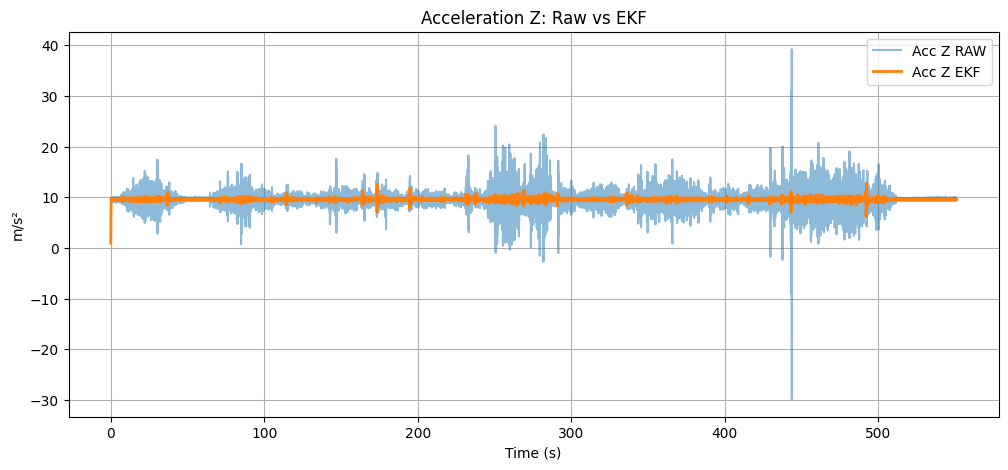

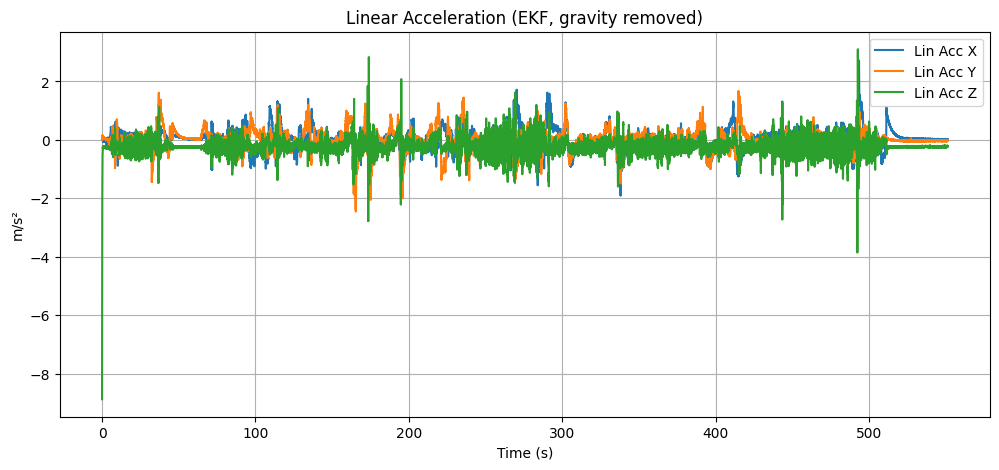

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────
# 1. Load EKF output
# ─────────────────────────────────────────────
df = pd.read_csv("ekf_output.csv")

t = df["t"].values
t = (t - t[0]) / 1000.0   # seconds

n = len(df)

# ─────────────────────────────────────────────
# 2. RAW IMU data (trimmed to match EKF)
# ─────────────────────────────────────────────
gyro_raw = imu_with_gps[["gyro_x", "gyro_y", "gyro_z"]].values[:n]
acc_raw  = imu_with_gps[["accel_x", "accel_y", "accel_z"]].values[:n]

# ─────────────────────────────────────────────
# 3. EKF outputs
# ─────────────────────────────────────────────
gyro_ekf = df[["gx", "gy", "gz"]].values
acc_ekf  = df[["ax", "ay", "az"]].values
lin_ekf  = df[["alin_x", "alin_y", "alin_z"]].values

# ─────────────────────────────────────────────
# 4. PLOTS
# ─────────────────────────────────────────────

# ── Gyro Z ─────────────────────────────
plt.figure(figsize=(12, 5))
plt.plot(t, gyro_raw[:, 2], label="Gyro Z RAW", alpha=0.5)
plt.plot(t, gyro_ekf[:, 2], label="Gyro Z EKF", linewidth=2)
plt.title("Gyro Z: Raw vs EKF")
plt.xlabel("Time (s)")
plt.ylabel("rad/s")
plt.grid()
plt.legend()
plt.show()

# ── Acc Z ─────────────────────────────
plt.figure(figsize=(12, 5))
plt.plot(t, acc_raw[:, 2], label="Acc Z RAW", alpha=0.5)
plt.plot(t, acc_ekf[:, 2], label="Acc Z EKF", linewidth=2)
plt.title("Acceleration Z: Raw vs EKF")
plt.xlabel("Time (s)")
plt.ylabel("m/s²")
plt.grid()
plt.legend()
plt.show()

# ── Linear acceleration (EKF) ─────────────────────────────
plt.figure(figsize=(12, 5))

plt.plot(t, lin_ekf[:, 0], label="Lin Acc X")
plt.plot(t, lin_ekf[:, 1], label="Lin Acc Y")
plt.plot(t, lin_ekf[:, 2], label="Lin Acc Z")

plt.title("Linear Acceleration (EKF, gravity removed)")
plt.xlabel("Time (s)")
plt.ylabel("m/s²")
plt.grid()
plt.legend()
plt.show()